In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

Dataset:
    Experience  Salary
0           1   45000
1           2   50000
2           3   60000
3           4   80000
4           5  110000
5           6  150000
6           7  200000


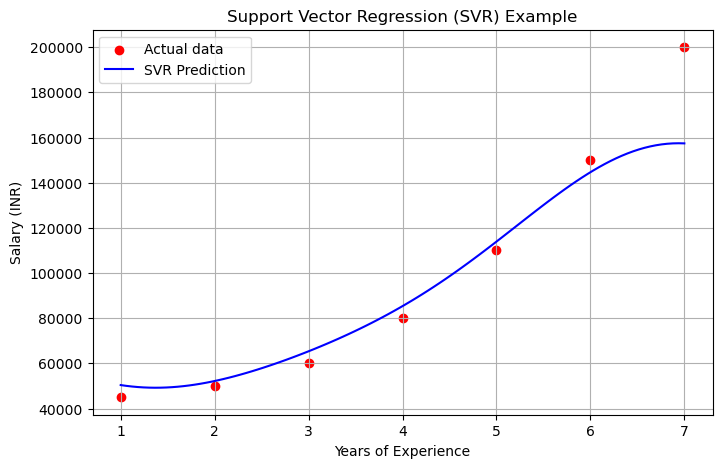

In [3]:
# --- Step 1: Create dataset ---
data = {
    "Experience" : [1,2,3,4,5,6,7],
    "Salary" : [45000, 50000, 60000, 80000, 110000, 150000, 200000]
}

df = pd.DataFrame(data)
print("Dataset:\n", df)

# --- Step 2: Train test Split Data
X = df[["Experience"]].values
y = df["Salary"].values.reshape(-1,1)

sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)

# --- Step 4: Train the SVR model ---

svr_model = SVR(kernel='rbf')
svr_model.fit(X_scaled, y_scaled.ravel())
# --- Step 5: Predict for plotting
X_range = np.linspace(min(X), max(X), 100).reshape(-1,1)
y_pred_scaled = svr_model.predict(sc_X.transform(X_range))
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))

# --- Step 6: Plot the result ---
plt.figure(figsize=(8,5))
plt.scatter(X,y, color='red', label='Actual data')
plt.plot(X_range, y_pred, color = 'blue', label='SVR Prediction')
plt.title("Support Vector Regression (SVR) Example")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (INR)")
plt.legend()
plt.grid(True)
plt.show()